In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("global_inflation_post_covid.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             100000 non-null  object 
 1   date                100000 non-null  object 
 2   inflation_rate      100000 non-null  float64
 3   interest_rate       100000 non-null  float64
 4   oil_price           100000 non-null  float64
 5   gdp_growth          100000 non-null  float64
 6   unemployment_rate   100000 non-null  float64
 7   money_supply_m2     100000 non-null  float64
 8   exchange_rate_usd   100000 non-null  float64
 9   food_price_index    100000 non-null  float64
 10  supply_chain_index  100000 non-null  float64
dtypes: float64(9), object(2)
memory usage: 8.4+ MB


,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958
std,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450
min,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000
25%,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000
50%,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000
75%,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000
max,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             100000 non-null  object 
 1   date                100000 non-null  object 
 2   inflation_rate      100000 non-null  float64
 3   interest_rate       100000 non-null  float64
 4   oil_price           100000 non-null  float64
 5   gdp_growth          100000 non-null  float64
 6   unemployment_rate   100000 non-null  float64
 7   money_supply_m2     100000 non-null  float64
 8   exchange_rate_usd   100000 non-null  float64
 9   food_price_index    100000 non-null  float64
 10  supply_chain_index  100000 non-null  float64
dtypes: float64(9), object(2)
memory usage: 8.4+ MB


country               0
date                  0
inflation_rate        0
interest_rate         0
oil_price             0
gdp_growth            0
unemployment_rate     0
money_supply_m2       0
exchange_rate_usd     0
food_price_index      0
supply_chain_index    0
dtype: int64

In [4]:
df.columns

Index(['country', 'date', 'inflation_rate', 'interest_rate', 'oil_price',
       'gdp_growth', 'unemployment_rate', 'money_supply_m2',
       'exchange_rate_usd', 'food_price_index', 'supply_chain_index'],
      dtype='object')

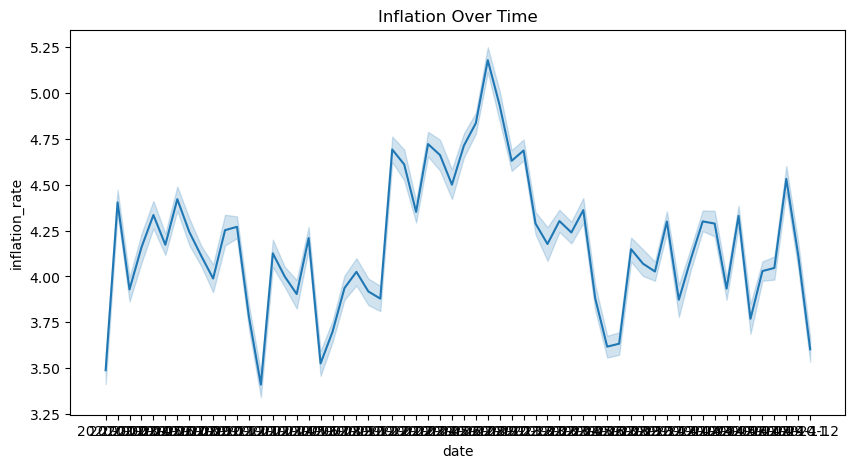

In [5]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="date", y="inflation_rate")
plt.title("Inflation Over Time")
plt.show()

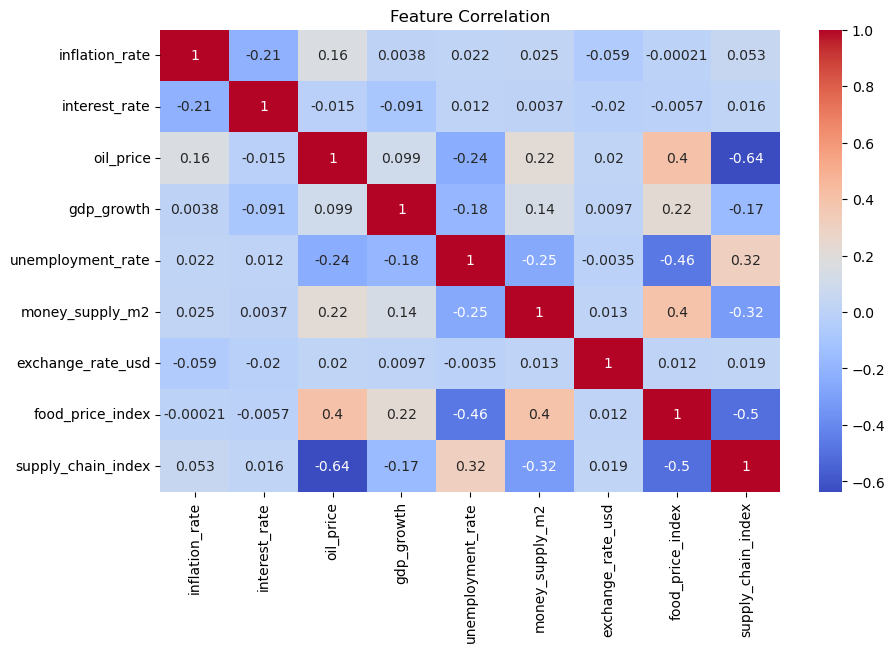

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# SAFEST approach: remove ALL non-numeric columns
df_clean = df.drop(columns=["country", "date"])

X = df_clean.drop("inflation_rate", axis=1)
y = df_clean["inflation_rate"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [8]:
model.score(X_test, y_test)


0.12143436070202829

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(1.3654570146861655)

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = rf_model.score(X_test, y_test)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.49385723767809225
Random Forest R²: 0.8850732847781475


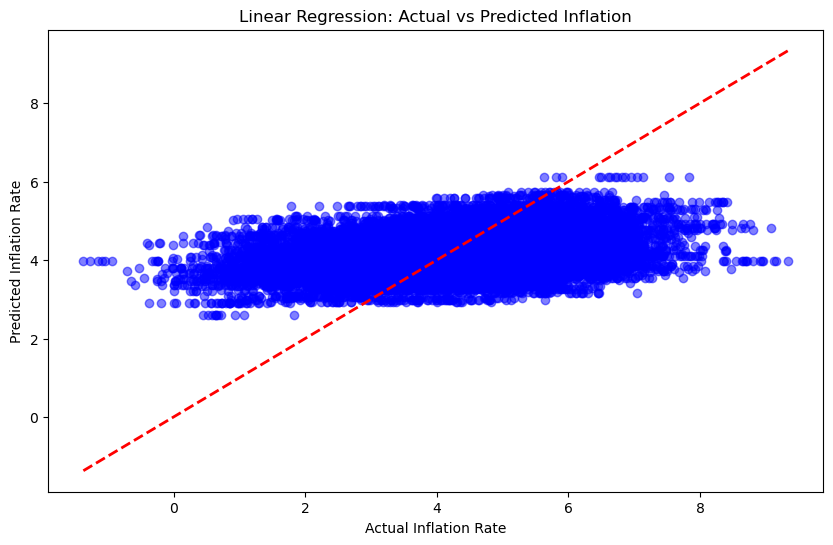

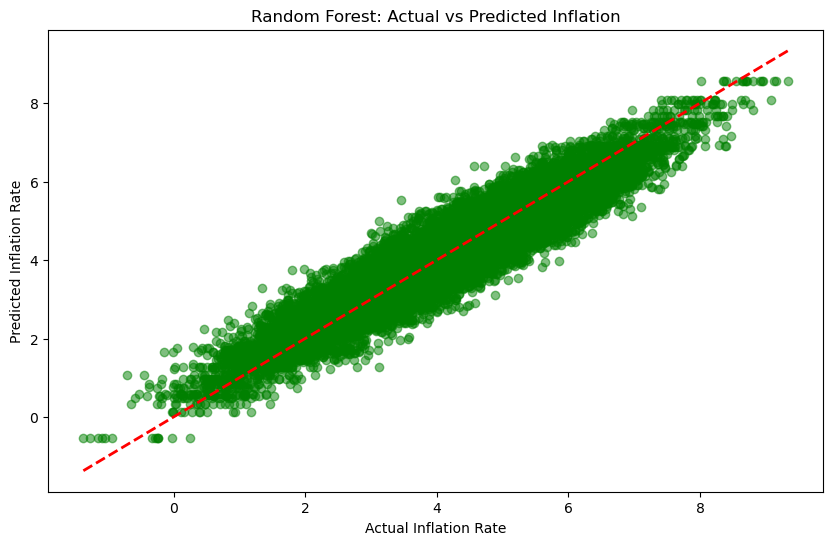

In [13]:
import matplotlib.pyplot as plt

# 1. Generate Linear Regression Results Plot (Figure 4)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue') # y_pred is your Linear Regression prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted Inflation')
plt.xlabel('Actual Inflation Rate')
plt.ylabel('Predicted Inflation Rate')
plt.show()

# 2. Generate Random Forest Results Plot (Figure 5)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green') # y_pred_rf is your Random Forest prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted Inflation')
plt.xlabel('Actual Inflation Rate')
plt.ylabel('Predicted Inflation Rate')
plt.show()